In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn  as sns

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

variables con las cuales trabajar: no_of_dependents, self_employed, income_annum, loan_amount, loan_term, loan_status. La variable objetivo será loan_status

In [4]:
df2 = df.drop(columns=[' cibil_score', 'loan_id', ' education',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value',])
df2[' self_employed'] = df2[' self_employed'].map({' No' : 0, ' Yes': 1})
df2[' loan_status'] = df2[' loan_status'].map({' Rejected' : 0, ' Approved': 1})

df2.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,loan_status
0,2,0,9600000,29900000,12,1
1,0,1,4100000,12200000,8,0
2,3,0,9100000,29700000,20,0
3,3,0,8200000,30700000,8,0
4,5,1,9800000,24200000,20,0


<Axes: xlabel=' loan_status', ylabel='count'>

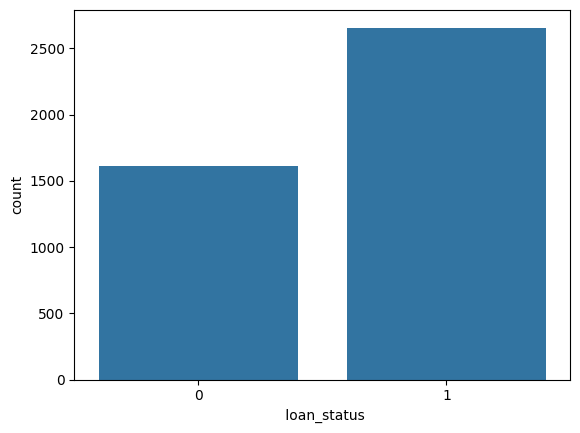

In [5]:
sns.countplot(x=" loan_status", data=df2)

In [6]:
X = df2.drop(" loan_status", axis=1)
y = df2[" loan_status"]

x_train, x_test,y_train, y_test = train_test_split(
    X,
    y, 
    train_size=0.8,
    random_state=42,
    stratify=y)


In [7]:
arbol = RandomForestClassifier(n_estimators=100, 
                               max_depth=10,
                               class_weight="balanced",
                               random_state=25)

In [8]:
arbol.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [9]:
arbol.feature_importances_

array([0.10473866, 0.04076582, 0.29297767, 0.35215765, 0.20936019])

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_prediccion = arbol.predict(x_test)

accuracy_score(y_test, y_prediccion)

0.5480093676814989

In [11]:
print(classification_report(y_test, y_prediccion))

              precision    recall  f1-score   support

           0       0.42      0.49      0.45       323
           1       0.65      0.59      0.62       531

    accuracy                           0.55       854
   macro avg       0.53      0.54      0.53       854
weighted avg       0.56      0.55      0.55       854



In [12]:
confusion_matrix(y_test, y_prediccion)

array([[157, 166],
       [220, 311]])

In [33]:
df3 = df2.copy()
df3[" loan_to_income"] = df3[" loan_amount"] / df3[" income_annum"]
df3[" monthly_income"] = df3[" income_annum"] / 12
df3[" estimated_monthly_payment"] = df3[" loan_amount"] / (df3[" loan_term"]*12)
df3[" payment_to_income"] = df3[" estimated_monthly_payment"] / df3[" monthly_income"]

df3.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,loan_status,loan_to_income,monthly_income,estimated_monthly_payment,payment_to_income
0,2,0,9600000,29900000,12,1,3.114583,800000.000000,207638.888889,0.259549
1,0,1,4100000,12200000,8,0,2.975610,341666.666667,127083.333333,0.371951
2,3,0,9100000,29700000,20,0,3.263736,758333.333333,123750.000000,0.163187
3,3,0,8200000,30700000,8,0,3.743902,683333.333333,319791.666667,0.467988
4,5,1,9800000,24200000,20,0,2.469388,816666.666667,100833.333333,0.123469


In [34]:
X = df3.drop(" loan_status", axis=1)
y = df3[" loan_status"]

x_train, x_test,y_train, y_test = train_test_split(
    X,
    y, 
    train_size=0.8,
    random_state=42,
    stratify=y)

In [35]:
arbol2 = RandomForestClassifier(n_estimators=100, 
                               max_depth=10,
                               class_weight="balanced",
                               random_state=25)

In [36]:
arbol2.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
arbol2.feature_importances_

array([0.05688467, 0.01817167, 0.08042648, 0.12036652, 0.08457357,
       0.18952246, 0.08517056, 0.14536493, 0.21951914])

In [38]:
y_prediccion = arbol2.predict(x_test)

accuracy_score(y_test, y_prediccion)

0.5480093676814989

In [39]:
print(classification_report(y_test, y_prediccion))

              precision    recall  f1-score   support

           0       0.43      0.58      0.49       323
           1       0.67      0.53      0.59       531

    accuracy                           0.55       854
   macro avg       0.55      0.55      0.54       854
weighted avg       0.58      0.55      0.55       854



In [40]:
confusion_matrix(y_test, y_prediccion)

array([[188, 135],
       [251, 280]])

In [41]:
proba_aprob = arbol2.predict_proba(x_test)[:, 1]

In [46]:
umbrales = [0.35, 0.40, 0.45, 0.55, 0.60, 0.65, 0.70, 0.73]

for umbral in umbrales:
    y_pred_umbral = (proba_aprob >= umbral).astype(int)

    print("Umbral:", umbral)
    print(confusion_matrix(y_test, y_pred_umbral))
    print(classification_report(y_test, y_pred_umbral))
    print("-" * 50)

Umbral: 0.35
[[ 12 311]
 [ 13 518]]
              precision    recall  f1-score   support

           0       0.48      0.04      0.07       323
           1       0.62      0.98      0.76       531

    accuracy                           0.62       854
   macro avg       0.55      0.51      0.42       854
weighted avg       0.57      0.62      0.50       854

--------------------------------------------------
Umbral: 0.4
[[ 40 283]
 [ 44 487]]
              precision    recall  f1-score   support

           0       0.48      0.12      0.20       323
           1       0.63      0.92      0.75       531

    accuracy                           0.62       854
   macro avg       0.55      0.52      0.47       854
weighted avg       0.57      0.62      0.54       854

--------------------------------------------------
Umbral: 0.45
[[107 216]
 [143 388]]
              precision    recall  f1-score   support

           0       0.43      0.33      0.37       323
           1       0.64     

In [44]:
arbol2.classes_

array([0, 1])

In [49]:
from sklearn.model_selection import GridSearchCV

arbol3 = RandomForestClassifier(
    n_estimators=100,
    random_state=25
)

param_grid = {
    "class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ]
}

In [52]:
grid = GridSearchCV(
    estimator=arbol3,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=25)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

In [54]:
print("Mejores parámetros:")
print(grid.best_params_)

print(grid.best_score_)

mejor_modelo = grid.best_estimator_

y_pred = mejor_modelo.predict(x_test)

print("Reporte en test:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Mejores parámetros:
{'class_weight': 'balanced_subsample'}
0.5316291385474188
Reporte en test:
              precision    recall  f1-score   support

           0       0.46      0.31      0.37       323
           1       0.65      0.78      0.71       531

    accuracy                           0.60       854
   macro avg       0.56      0.54      0.54       854
weighted avg       0.58      0.60      0.58       854

Matriz de confusión:
[[ 99 224]
 [115 416]]
